In [62]:
# %pip install -q seaborn

In [63]:
import numpy as np
import pandas as pd
import seaborn as sns # type: ignore
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")


def show_layout():
    plt.figure(figsize=(9, 4))
    plt.tight_layout()
    plt.show()

In [64]:
df = pd.read_csv(
    r"C:\Users\AYO_AYO\Desktop\Machine-Learning-Bootcamp\CSV-Excel\Datasets\titanic_dataset.csv")

In [65]:
df.shape

(891, 15)

In [66]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [67]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

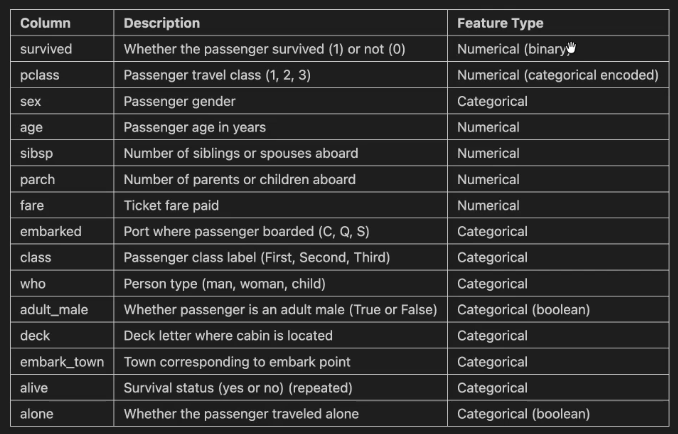

In [68]:
num_cols = df.select_dtypes([np.number]).columns.to_list()
cat_cols = [col for col in df.columns if col not in num_cols]

print(num_cols)
print(cat_cols)

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


**Numerical Feature Analysis**

In [69]:
df[num_cols].head()

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


**Numerical Statistics**

In [70]:
print("-" * 15, "Summary Statistics", "-" * 15)
print(df[num_cols].describe())
print("-"*20)
print(df[num_cols].isna().sum())

--------------- Summary Statistics ---------------
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200
--------------------
survived      0
pclass        0
age         177
sibsp         0
parch         0
fare          0
dtype: int64


In [71]:
print("Mean:") 
print(df[num_cols].mean())

print("-"*10)

print("Median:") 
print(df[num_cols].median())

print("-"*10)

print("Mode")
print(df["age"].mode()[0])

# print(df[["age", "fare"]].mode().iloc[0])

Mean:
survived     0.383838
pclass       2.308642
age         29.699118
sibsp        0.523008
parch        0.381594
fare        32.204208
dtype: float64
----------
Median:
survived     0.0000
pclass       3.0000
age         28.0000
sibsp        0.0000
parch        0.0000
fare        14.4542
dtype: float64
----------
Mode
24.0


**Measure of spread (Variance, STD, Range)**

In [72]:
print("Mean:")
print(df[num_cols].mean().sort_values(ascending=False))

print()
print("Variance")
print(df[num_cols].var().sort_values(ascending=False))

print()

print("Standard Dev")
print(df[num_cols].std().round(2))

Mean:
fare        32.204208
age         29.699118
pclass       2.308642
sibsp        0.523008
survived     0.383838
parch        0.381594
dtype: float64

Variance
fare        2469.436846
age          211.019125
sibsp          1.216043
pclass         0.699015
parch          0.649728
survived       0.236772
dtype: float64

Standard Dev
survived     0.49
pclass       0.84
age         14.53
sibsp        1.10
parch        0.81
fare        49.69
dtype: float64


**Skewness & Kurtosis**

In [74]:
print(df[num_cols].skew())
print(df[num_cols].kurtosis())

survived    0.478523
pclass     -0.630548
age         0.389108
sibsp       3.695352
parch       2.749117
fare        4.787317
dtype: float64
survived    -1.775005
pclass      -1.280015
age          0.178274
sibsp       17.880420
parch        9.778125
fare        33.398141
dtype: float64


**Visualization**

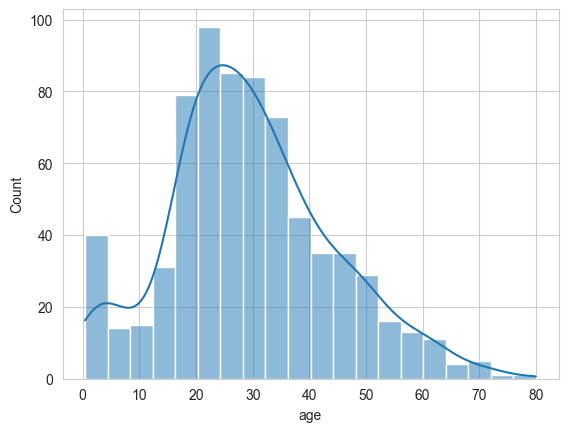

<Figure size 900x400 with 0 Axes>

In [75]:
sns.histplot(df["age"], kde=True)
show_layout()

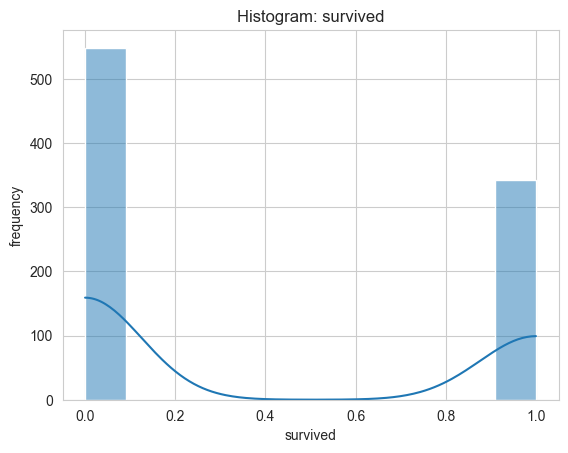

<Figure size 900x400 with 0 Axes>

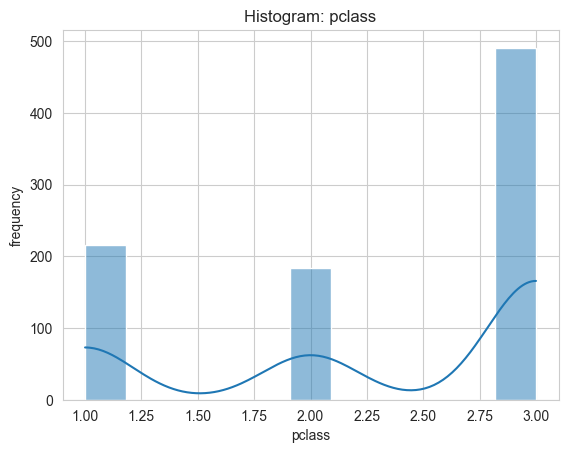

<Figure size 900x400 with 0 Axes>

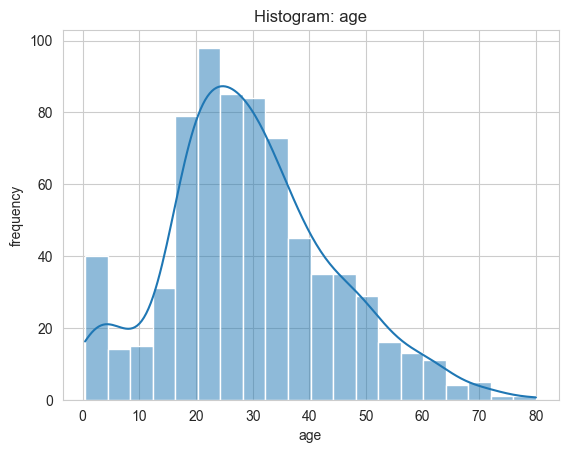

<Figure size 900x400 with 0 Axes>

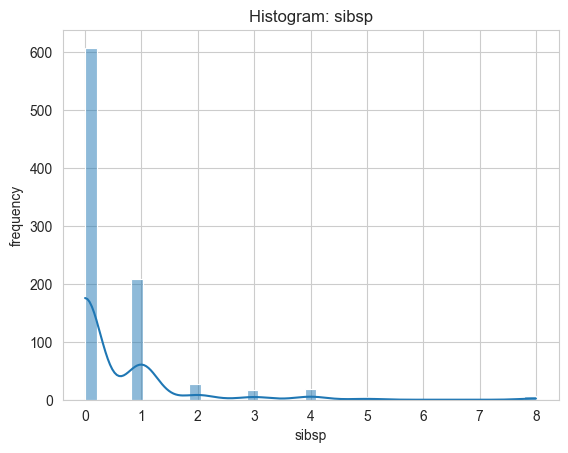

<Figure size 900x400 with 0 Axes>

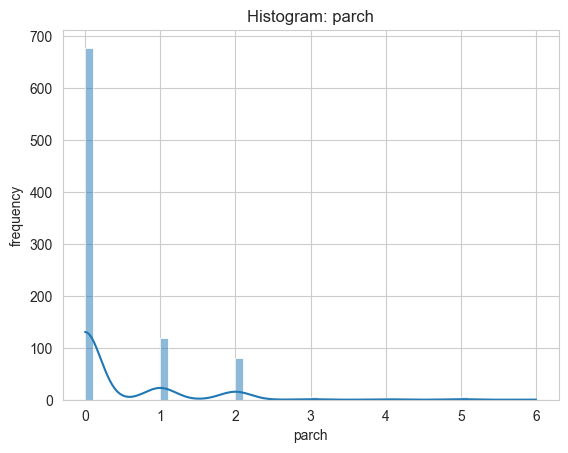

<Figure size 900x400 with 0 Axes>

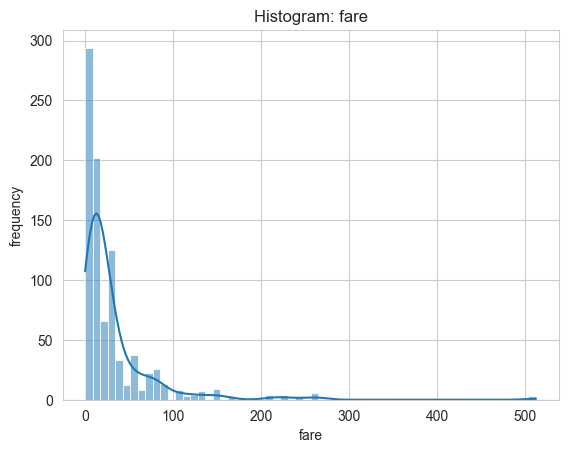

<Figure size 900x400 with 0 Axes>

In [76]:
for col in df[num_cols]:
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    show_layout()

**Box Plot**

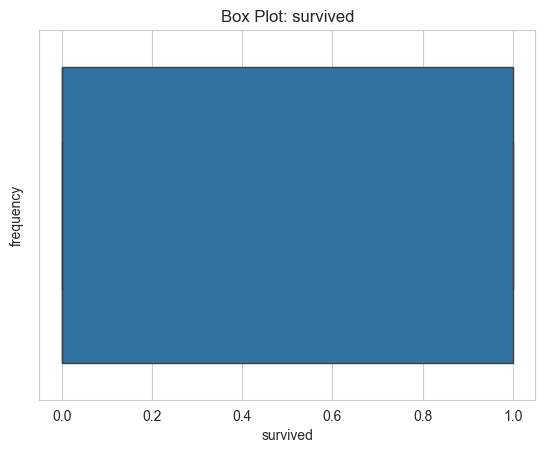

<Figure size 900x400 with 0 Axes>

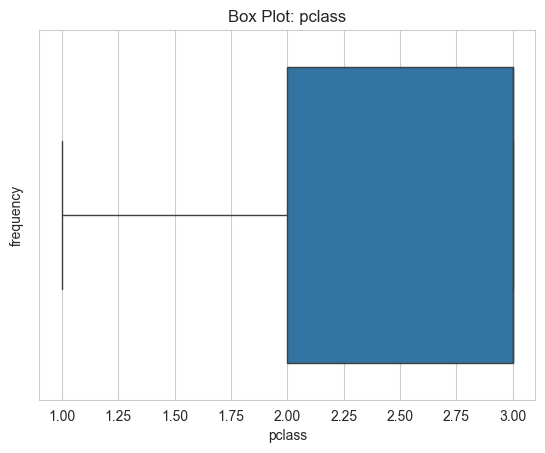

<Figure size 900x400 with 0 Axes>

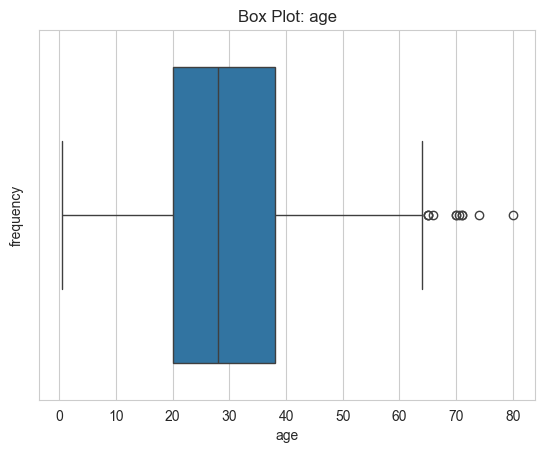

<Figure size 900x400 with 0 Axes>

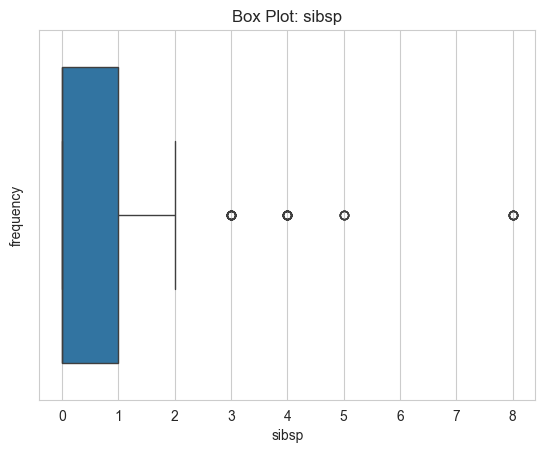

<Figure size 900x400 with 0 Axes>

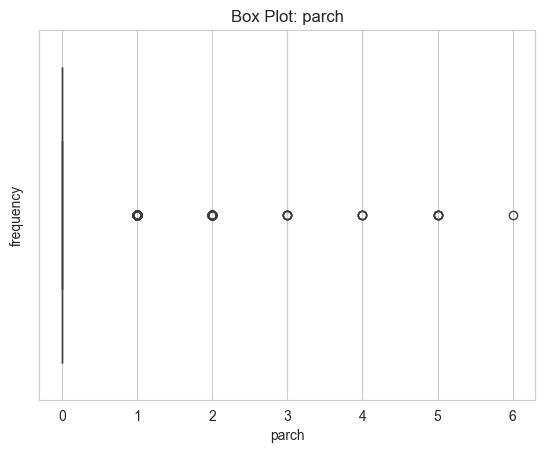

<Figure size 900x400 with 0 Axes>

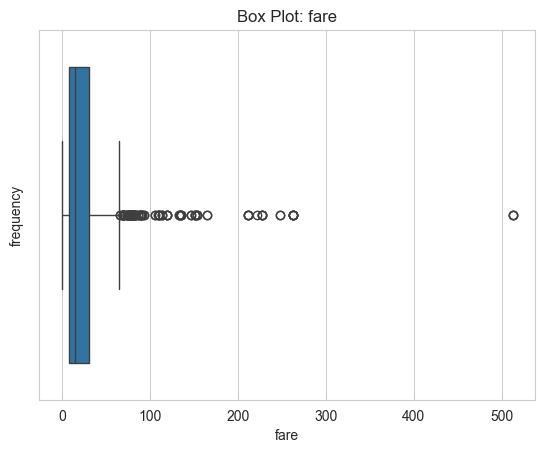

<Figure size 900x400 with 0 Axes>

In [77]:
for col in df[num_cols]:
    sns.boxplot(x = df[col])
    plt.title(f"Box Plot: {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    show_layout()

### Categorical Feature - Analysis

In [78]:
df[cat_cols].head()

,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,male,S,Third,man,True,NaN,Southampton,no,False
1,female,C,First,woman,False,C,Cherbourg,yes,False
2,female,S,Third,woman,False,NaN,Southampton,yes,True
3,female,S,First,woman,False,C,Southampton,yes,False
4,male,S,Third,man,True,NaN,Southampton,no,True


In [79]:
print("Normal Distribution")
print(df["class"].value_counts())
print("*"*20)
print("Percentage Distribution")
print(df["class"].value_counts(normalize=True))

Normal Distribution
class
Third     491
First     216
Second    184
Name: count, dtype: int64
********************
Percentage Distribution
class
Third     0.551066
First     0.242424
Second    0.206510
Name: proportion, dtype: float64


In [80]:
for col in df[cat_cols]:
    print("Normal Distribution")
    print(df[col].value_counts())
    print("*"*20)
    print("Percentage Distribution")
    print(df[col].value_counts(normalize=True))

Normal Distribution
sex
male      577
female    314
Name: count, dtype: int64
********************
Percentage Distribution
sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64
Normal Distribution
embarked
S    644
C    168
Q     77
Name: count, dtype: int64
********************
Percentage Distribution
embarked
S    0.724409
C    0.188976
Q    0.086614
Name: proportion, dtype: float64
Normal Distribution
class
Third     491
First     216
Second    184
Name: count, dtype: int64
********************
Percentage Distribution
class
Third     0.551066
First     0.242424
Second    0.206510
Name: proportion, dtype: float64
Normal Distribution
who
man      537
woman    271
child     83
Name: count, dtype: int64
********************
Percentage Distribution
who
man      0.602694
woman    0.304153
child    0.093154
Name: proportion, dtype: float64
Normal Distribution
adult_male
True     537
False    354
Name: count, dtype: int64
********************
Percentage Distribution
adu

**Countplot**

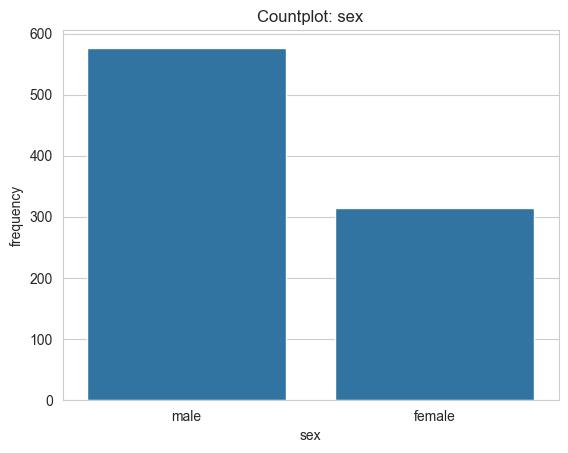

<Figure size 900x400 with 0 Axes>

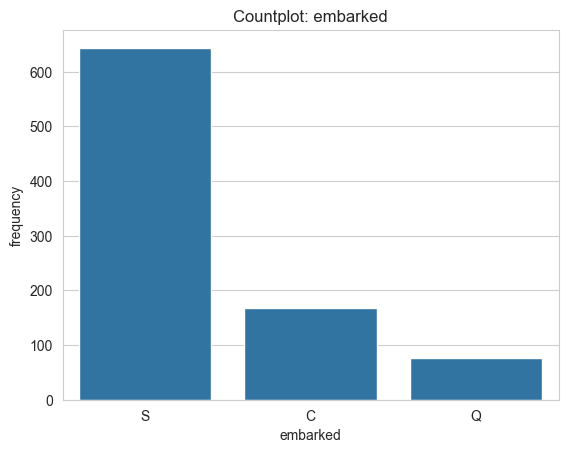

<Figure size 900x400 with 0 Axes>

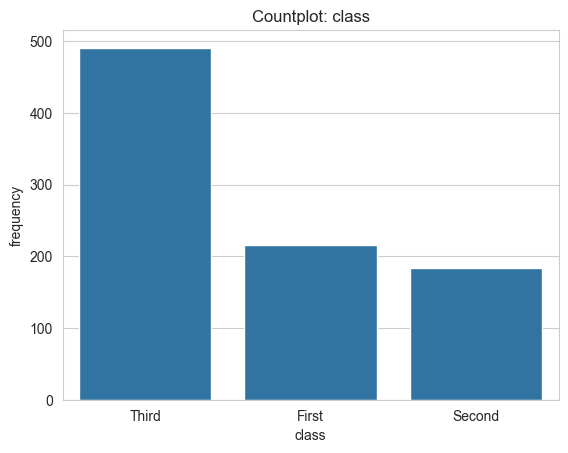

<Figure size 900x400 with 0 Axes>

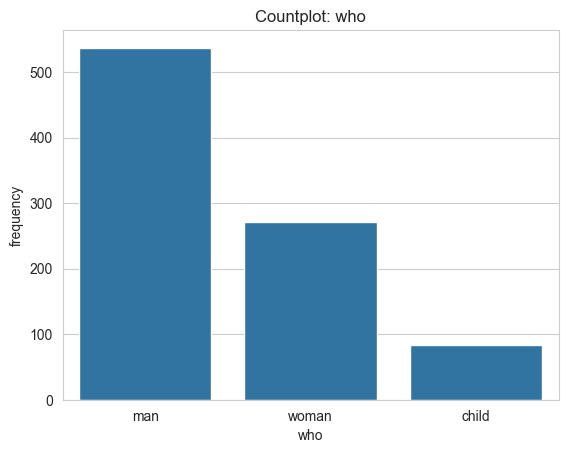

<Figure size 900x400 with 0 Axes>

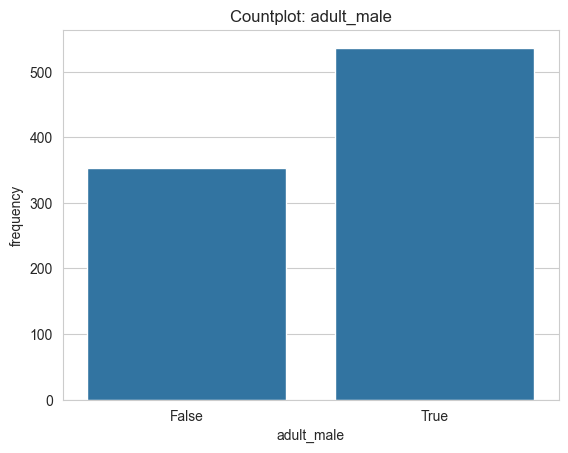

<Figure size 900x400 with 0 Axes>

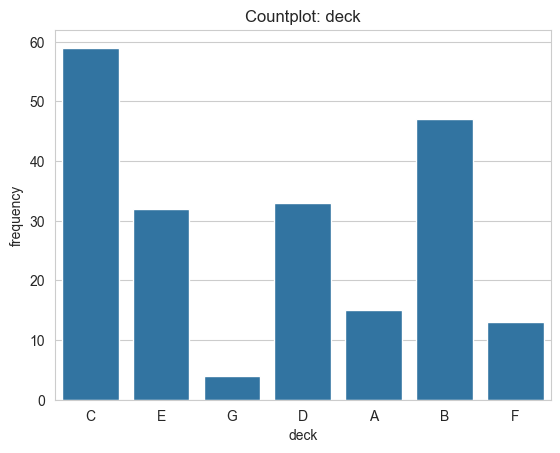

<Figure size 900x400 with 0 Axes>

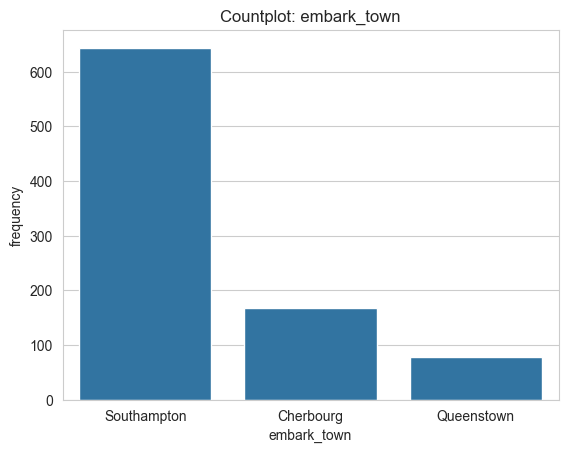

<Figure size 900x400 with 0 Axes>

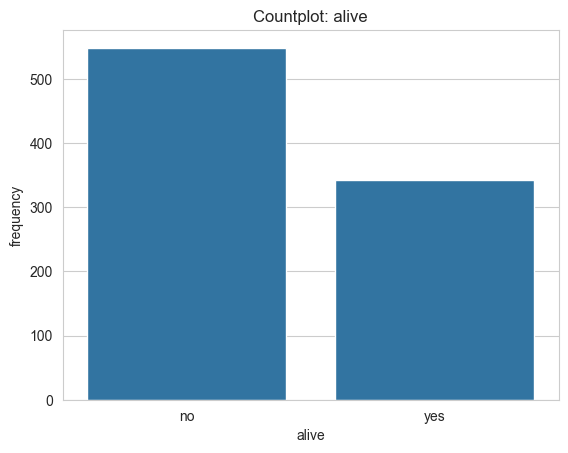

<Figure size 900x400 with 0 Axes>

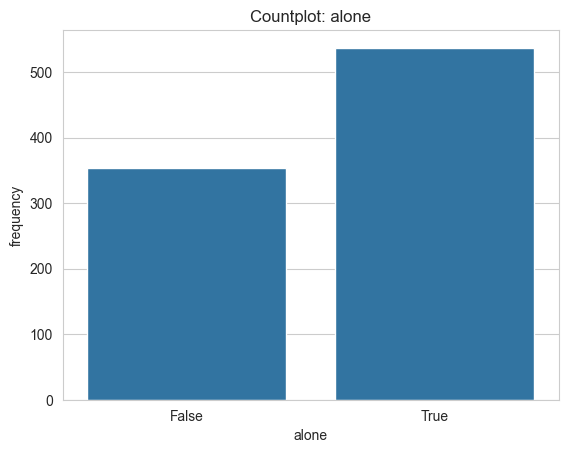

<Figure size 900x400 with 0 Axes>

In [81]:
for col in df[cat_cols]:
    sns.countplot(x = df[col], )
    plt.title(f"Countplot: {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    show_layout()

Univariate analysis completed.
- Numerical statistics calculated
- Skewness and kurtosis printed
- Histograms and boxplots plotted
- Categorical frequency tables and countplots created

Key findings - Univariate Analysis:

Univariate analysis helps us understand each feature independently before modeling. Here is what we learned from the Titanic dataset:

1. Numerical features show varying scales and strong skewness, especially fare. This indicates a need for scaling and possibly log transformation. Age has moderate variability and can be imputed reliably.
2. Categorical features show clear imbalance in groups like sex, pclass, and embarked. These patterns will influence the model and require careful encoding.
3. Outliers are present in fare and family related columns. Tree based models handle them well, but linear models will need scaling or outlier treatment.
4. Most passengers traveled alone, which supports creating engineered features like family_size for improved predictions.
5. Visualizations like histograms and boxplots reveal distribution shape, long tails, and unusual values, while countplots expose dominance of certain categories.